In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.image as mpimg
import matplotlib.ticker as ticker
import os
import wandb
import pandas as pd
import re
import json
import glob
from matplotlib.gridspec import GridSpec
import tempfile
import numpy as np
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# --- 1. Global Styling to match Academic/LaTeX style ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm", # Computer Modern style for math
    "axes.grid": True,
    "grid.alpha": 0.5,
    "grid.linestyle": "--"
})

plt.rcParams.update({
    "text.usetex": True,           # Enable full LaTeX
    "font.family": "serif",        # Serif font like the picture
    "font.serif": ["Times New Roman", "Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{type1cm}\usepackage{amssymb}", # CRITICAL: Loads \lVert
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "-"          # Solid light lines like the reference
})

In [ ]:
def download_tables(run_id, output_dir):
    # 初始化 W&B API
    api = wandb.Api()

    # your entity and project name
    entity = "your_entity"
    project = "HTnoise"

    run = api.run(f"{entity}/{project}/{run_id}")
    os.makedirs(output_dir, exist_ok=True)

    processed_paths = set()

    for row in run.scan_history(keys=None, page_size=1000):
        for key, value in row.items():
            if isinstance(value, dict) and value.get("_type") == "table-file":
                file_path = value["path"]  # e.g., "media/table/xxx.table.json"
                
                if file_path in processed_paths:
                    continue
                processed_paths.add(file_path)
                
                print(f"📄 Found table: key='{key}', file='{file_path}'")
                
                try:
                    remote_file = run.file(file_path)
                    if not remote_file:
                        print(f"  ⚠️ File not found: {file_path}")
                        continue
                    
                    local_path = remote_file.download(replace=True).name
                    
                    with open(local_path, "r") as f:
                        table_json = json.load(f)
                    
                    df = pd.DataFrame(table_json["data"], columns=table_json["columns"])
                    
                    safe_key = "".join(c if c.isalnum() or c in ("_", "-") else "_" for c in key)
                    csv_path = os.path.join(output_dir, f"{safe_key}.csv")
                    
                    df.to_csv(csv_path, index=False)
                    print(f"✅ Saved as: {safe_key}.csv")
                    
                    os.remove(local_path)
                    
                except Exception as e:
                    print(f"❌ Failed to process '{key}': {e}")

    print("\n🎉 All tables exported with original names!")

In [ ]:
run_ids = []
for run_id in run_ids:
    download_tables(run_id, "./data")

In [5]:
def draw_gradient(file_path):
    print(file_path)
    df = pd.read_csv(file_path)
    df['relative_itr'] = df['itr'] - df['itr'].min()

    fig, ax = plt.subplots(figsize=(12, 9))

    sc = ax.scatter(
        df['nabla_norm'], 
        df['noise_norm'], 
        c=df['relative_itr'], 
        cmap='viridis', 
        s=50, 
        alpha=0.7,
        edgecolors='none'
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Relative Iteration Count')

    ax.set_xlabel('Absolute Gradient Value (Log Scale)')
    ax.set_ylabel('Noise Value (Log Scale)')

    filename = os.path.basename(file_path)
    match = re.match(r'opt_(.*)_type_(.*)_itr_(\d+)\.csv$', filename)
    
    opt_name = match.group(1)
    ax.set_title(opt_name)

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.grid(True, linestyle='--', alpha=0.4)

    return fig

data/c4/embedding/opt_muon_type_coordinate-576778_itr_0.csv


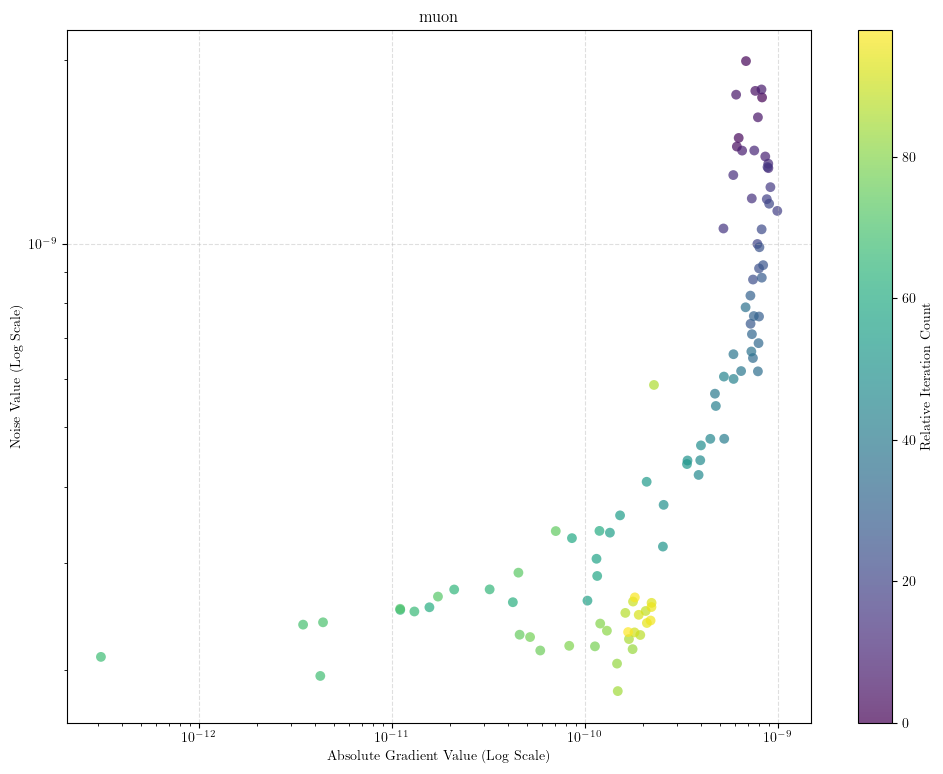

In [ ]:
fig = draw_gradient(
    "path_to_table"
)

In [ ]:
def process_all(data_folder, output_folder, correlation_threshold = 0.1):
    os.makedirs(output_folder, exist_ok=True)
    csv_files = glob.glob(os.path.join(data_folder, '*.csv'))
    
    # Strictly maintain your requested order
    optimizer_order = ["adamw", "muon", "dmuon", "lion", "signum"]
    
    clusters = {}
    for file_path in csv_files:
        filename = os.path.basename(file_path)
        match = re.match(r'opt_(.*)_type_(.*)_itr_(\d+)\.csv$', filename)
        if not match: continue
        
        opt_name, type_name, itr = match.groups()
        key = (type_name, int(itr))
        if key not in clusters: clusters[key] = {}
        clusters[key][opt_name] = file_path

    for (type_name, itr), opt_dict in clusters.items():
        present_opts = [opt for opt in optimizer_order if opt in opt_dict]
        N = len(present_opts)
        if N == 0: continue

        is_good_relationship = True
        
        if "coordinate" in type_name:
            for opt in present_opts:
                df_check = pd.read_csv(opt_dict[opt])
                # Filter itrs like in the drawing logic
                df_check = df_check[df_check['itr'] - df_check['itr'].min() <= 100]
                
                # Calculate correlation in log-space
                log_x = np.log10(df_check['nabla_norm'].replace(0, np.nan)).dropna()
                log_y = np.log10(df_check['noise_norm'].replace(0, np.nan)).dropna()
                
                # Ensure we have enough data points to correlate
                if len(log_x) < 5:
                    is_good_relationship = False
                    break
                    
                corr = log_x.corr(log_y)
                
                # If any optimizer in the set shows a negative or weak correlation, 
                # we skip this coordinate to keep the "cherry-picked" results clean.
                if pd.isna(corr) or corr < correlation_threshold:
                    is_good_relationship = False
                    break

        if not is_good_relationship:
            continue

        # --- 2. Grid Setup ---
        ncols = 2 
        nrows = (N + ncols - 1) // ncols
        
        # constrained_layout ensures every plot keeps its labels/titles/colorbars
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), constrained_layout=True)
        
        # Flatten axes and handle single-plot case
        if N == 1:
            axes_flat = [axes]
        else:
            axes_flat = axes.flatten()

        is_coordinate_wise = False
        index = 0
        if "coordinate" in type_name:
            is_coordinate_wise = True
            match = re.match(r"coordinate-(\d+)", type_name)
            index = int(match.group(1))

        for i, opt_name in enumerate(present_opts):
            ax = axes_flat[i]
            df = pd.read_csv(opt_dict[opt_name])
            
            # Data processing from your original logic
            df['relative_itr'] = df['itr'] - df['itr'].min()
            df = df[df['relative_itr'] <= 100]

            # --- 3. Scatter Plot ---
            sc = ax.scatter(
                df['nabla_norm'],
                df['noise_norm'],
                c=df['relative_itr'],
                cmap='viridis',
                s=40,
                alpha=0.8,
                edgecolors='none'
            )

            # --- 4. Title and Original Labels (with Serif Style) ---
            
            if is_coordinate_wise:
                ax.set_title(f"Ass. 4a with j = {index} on {opt_name}", fontsize=16)
                ax.set_xlabel(r'$\lVert \nabla_j f \rVert^p$ (Log Scale)', fontsize=16)
                ax.set_ylabel(r'$\mathbb{E} \lVert \nabla G_j - \nabla_j f \rVert^p$ (Log Scale)', fontsize=16)
            else:
                ax.set_title(f"Ass. 4c on {opt_name}", fontsize=16)
                ax.set_xlabel(r'$\lVert \nabla f \rVert_*^p$ (Log Scale)', fontsize=16)
                ax.set_ylabel(r'$\mathbb{E} [\lVert V_0 \rVert_*^{p/2} \lVert \nabla G_j - \nabla_j f \rVert^p_{|V_0|^{-1}}$] (Log Scale)', fontsize=16)
            # --- 5. Scale and Ticks ---
            ax.set_xscale('log')
            ax.set_yscale('log')
            
            # Ensure tick labels are visible on every subplot
            ax.tick_params(labelbottom=True, labelleft=True, which='both')

            # --- 6. Colorbar (Independent for each plot) ---
            cbar = fig.colorbar(sc, ax=ax, shrink=0.9)
            cbar.set_label('Relative Iteration Count', fontsize = 16)

        # --- 7. Save ---
        if is_coordinate_wise:
            save_name = f"4a-{index}"
        else:
            save_name = "4c"
        save_path = os.path.join(output_folder, f"{save_name}_itr_{itr}.pdf")
        plt.savefig(save_path, dpi=512)
        plt.close(fig)
        print(f"Generated Figure: {save_path}")

In [ ]:
def remove_outliers_iqr(df, column_name):
    # remove values that are extremely large.
    Q1 = df[column_name].quantile(0.05)
    Q3 = df[column_name].quantile(0.95)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]

def plot_horizontal_histograms(csv_folder, target_column, output_pdf="distribution_of_norm.pdf"):
    file_paths = sorted(glob.glob(os.path.join(csv_folder, "*.csv")))
    num_files = len(file_paths)
    
    if num_files == 0: return

    sub_width = 5
    sub_height = 4
    fig, axes = plt.subplots(nrows=1, ncols=num_files, 
                             figsize=(sub_width * num_files, sub_height))
    
    if num_files == 1: axes = [axes]

    for i, file_path in enumerate(file_paths):
        file_name = os.path.basename(file_path).replace(".csv", "")
        df = pd.read_csv(file_path, dtype={ target_column: str })
        df[target_column] = df[target_column].str.replace(r'[\[\]]', '', regex=True).astype(float)
        clean_df = remove_outliers_iqr(df, target_column)
        data = clean_df[target_column]

        ax = axes[i]
        ax.hist(data, bins=60, alpha=1.0, rwidth=1.0)
        ax.set_xlabel("Gradient error", fontsize=14)
        if i == 0:
            ax.set_ylabel("Counts", fontsize=16)
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax_ins = inset_axes(ax, width="40%", height="50%", loc='upper right', borderpad=1)
        
        qqplot(data, line='45', fit=True, ax=ax_ins, 
               marker='o', markersize=3, 
               alpha=0.5)
    
        ax_ins.get_lines()[1].set_linewidth(1.5)
        ax_ins.set_title("")
        ax_ins.set_xlabel("")
        ax_ins.set_ylabel("")
        ax_ins.set_xticks([])
        ax_ins.set_yticks([])

    plt.tight_layout()
    plt.savefig(output_pdf, dpi=512, bbox_inches='tight')
    plt.close()